In [1]:
#roc curve and auc
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
#generate 2 class dataset
x,y=make_classification(n_samples=1000,n_classes=2,random_state=1)

In [3]:
#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.25)

In [4]:
#generate a no skill prediction(major class)
#created a dummy model with default value of 0
dummy_model_prob=[0 for _ in range(len(y_test))]
#dummy_model_prob

In [5]:
#lets create basic logestic model
model=LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
#prediction based on probability 
model_prob=model.predict_proba(x_test)
#model_prob

In [7]:
#lets focus on the positive outcome
model_prob=model_prob[:,1]

In [8]:
#scores calculation
dummy_model_auc=roc_auc_score(y_test,dummy_model_prob)
model_auc=roc_auc_score(y_test,model_prob)
print(dummy_model_auc)
print(model_auc)

0.5
0.9108885464817668


In [9]:
#calculate ROC curves
dummy_fpr,dummy_tpr, _ =roc_curve(y_test,dummy_model_prob)
model_fpr,model_tpr, thresholds=roc_curve(y_test,model_prob)

In [10]:
#model_fpr,model_tpr

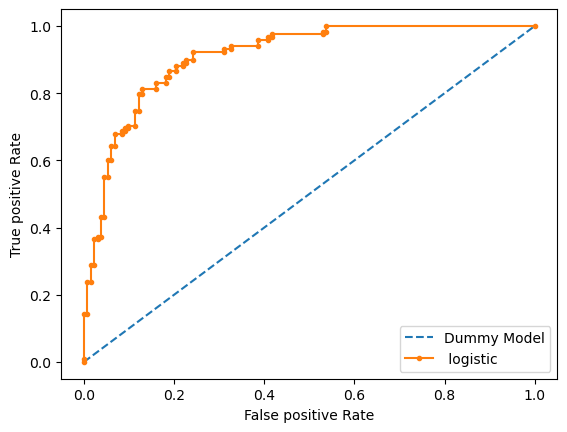

In [11]:
#plot the roc curve for the  model
pyplot.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy Model')
pyplot.plot(model_fpr,model_tpr,marker='.',label=' logistic')
#axis labels 
pyplot.xlabel('False positive Rate')
pyplot.ylabel('True positive Rate')
#show the legend
pyplot.legend()
#show the plot
pyplot.show()

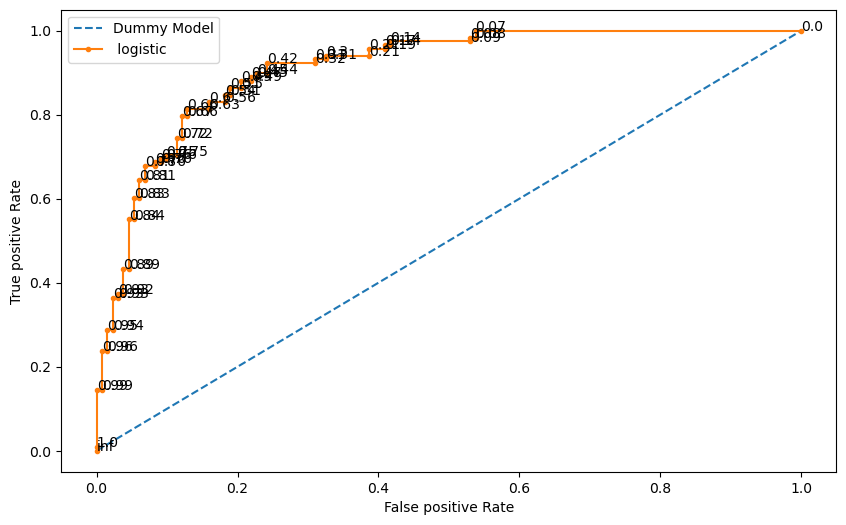

In [22]:
fig,ax= pyplot.subplots(figsize=(10,6))
ax.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy Model')
ax.plot(model_fpr,model_tpr,marker='.',label=' logistic')
#ax=fig.add_subplot(111)
for xyz in zip(model_fpr,model_tpr,thresholds):
    ax.annotate(round(xyz[2],2),xy=(xyz[0],xyz[1]))
#axis labels 
ax.set_xlabel('False positive Rate')
ax.set_ylabel('True positive Rate')
#show the legend
ax.legend()
#show the plot
pyplot.show()